# Мататематички методи за машинско учење 2025/26
## Домаћи задатак број 2

<div class="alert alert-block alert-danger">
<b>Име и презиме студента:</b> Danilo Milošević

<b>Број индекса:</b> 1732
    
</div>    

<div class="alert alert-block alert-info">
<b>Упутство за израду и предају домаћег задатака: </b> 
    
    1. Пре почетка израде промените име датотеке у 01Domaci_Ime_Prezime. (убаците своје име и презиме) 
    2. Попуните ћелију испод наслова одговарајућим подацима. 
    1. Употреба ћирилице није обавезна за предају домаћег задатка.
    4. За решавање задатака, уколико је потребно, отворите испод текста задатка додатне ћелије за уписивање текстуалног одговора (Markdown) или програмског кода (Code).
    1. Сва израчунавања, уколико је потребно, вршити у Python-у.
    5. Након завршетка израде решења домаћег Notebook документ сачувати у pdf формату и проследити га наставнику. То можете да урадите или кроз Teams или на мејл адресу jovana.dzunic@elfak.ni.ac.rs

</div> 

In [61]:
import numpy as np
import numpy.random as rndm
import matplotlib as mplb
import matplotlib.pyplot as plt
from timeit import default_timer as timer

**Задатак 1.**
Полином трећег степена $P(x)$ задовољава следеће услове: 
$$P(0)=1, \quad P'(0)=0, \quad P(1)=2, \quad P''(1)=0.$$

а) Формирати систем линеарних једначина за непознате коефицијенте полинома $P(x) = ax^3+bx^2+cx+d$ и решити га аналитички или матрично.

(5 поена)

\begin{align*}
P(x) &= ax^3 + bx^2 + cx + d \\
P'(x) &= 3ax^2 + 2bx + c\\
P''(x) &= 6ax + 2b\\
\\
P(0) &= 1 \Rightarrow 0 \cdot a + 0 \cdot b + 0 \cdot c + 1 \cdot d = 1\\
P'(0) &= 0 \Rightarrow 0 \cdot a + 0 \cdot b + 1 \cdot c + 0 \cdot d = 0\\
P(1) &= 2 \Rightarrow 1 \cdot a + 1 \cdot b + 1\cdot c + 1 \cdot d = 2\\
P''(1) &= 0 \Rightarrow 6 \cdot a + 2 \cdot b + 0 \cdot c + 0 \cdot d = 0\\
\\

A &=
\begin{bmatrix}
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
1 & 1 & 1 & 1 \\
6 & 2 & 0 & 0
\end{bmatrix}\\

b &= 
\begin{bmatrix}
1 \\
0 \\
2 \\
0
\end{bmatrix}\\

A \cdot \begin{bmatrix}a&b&c&d \end{bmatrix}^T &= b
\end{align*}



In [62]:
A_mat = np.array([
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [1, 1, 1, 1],
    [6, 2, 0, 0]
], dtype=float)
b_vec = np.array([1, 0, 2, 0], dtype=float)

koef = np.linalg.solve(A_mat, b_vec)
a, b, c, d = koef
print(f"Koeficijenti: a={a}, b={b}, c={c}, d={d}")
print(f"P(x) = {a}x^3 + {b}x^2 + {c}x + {d}")

Koeficijenti: a=-0.4999999999999999, b=1.4999999999999998, c=0.0, d=1.0
P(x) = -0.4999999999999999x^3 + 1.4999999999999998x^2 + 0.0x + 1.0


$$
P(x) = -0.5x^3 + 1.5 x^2 + 1
$$

б) Проверити добијени резултат. Приказати график полинома.

(5 поена)

P(0) = 1.000000  (treba 1)
P(1) = 2.000000  (treba 2)
P'(0) = 0.000000  (treba 0)
P''(1) = 0.000000  (treba 0)


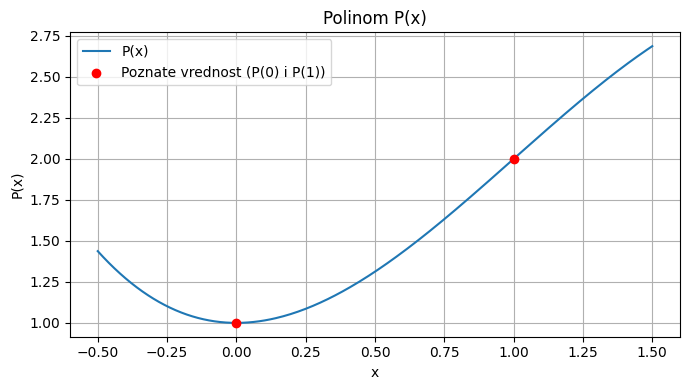

In [63]:
def P(x):
    return a*x**3 + b*x**2 + c*x + d

print(f"P(0) = {P(0):.6f}  (treba 1)")
print(f"P(1) = {P(1):.6f}  (treba 2)")
print(f"P'(0) = {c:.6f}  (treba 0)")
print(f"P''(1) = {6*a + 2*b:.6f}  (treba 0)")

x_plot = np.linspace(-0.5, 1.5, 300)
plt.figure(figsize=(7, 4))
plt.plot(x_plot, P(x_plot), label='P(x)')
plt.scatter([0, 1], [1, 2], color='red', zorder=5, label='Poznate vrednost (P(0) i P(1))')
plt.xlabel('x'); plt.ylabel('P(x)')
plt.title('Polinom P(x)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

***

**Задатак 2.** Да ли постоји полином трећег степена који пролази кроз следеће тачке
$$\begin{array}{c||c|c|c|c|c|c}
x_k&1&-2&0&3&-1&7\\\hline
y_k&-2&-56&-2&4&-16&376
\end{array}.$$ 
Образложити свој одговор.

(10 поена)

Da li polinom 
$$
P(x_k) = y_k \\
P(x) = ax^3+bx^2+cx+d
$$
postoji ćemo odrediti tako što ćemo na osnovu datih vrednosti $x$ formirati Vandermondovu matricu gde su kolone dobijene računanjem stepena $x^3$, $x^2$, $x^1$ i $x^0$ (tj 1)
$$
V = [x_k^3 | x_k^2 | x_k^1 | 1]
$$
a zatim rešiti jednačinu

$$
V * \begin{bmatrix}a & b & c & d \end{bmatrix}^T  = y
$$

Ukoliko dobijemo $\begin{bmatrix}a & b & c & d \end{bmatrix}$ za koje je ostatak (rezidual) nula ili zanemarljivo mali, polinom postoji

In [64]:
x_data = np.array([1, -2, 0, 3, -1, 7], dtype=float)
y_data = np.array([-2, -56, -2, 4, -16, 376], dtype=float)

V = np.column_stack([x_data**3, x_data**2, x_data, np.ones_like(x_data)])
print("Vandermondova matrica (6x4):")
print(V)

koef, resid, _, _ = np.linalg.lstsq(V, y_data, rcond=None)
print(f"\nResenje: a = {koef[0]:.4f}, b = {koef[1]:.4f}, c = {koef[2]:.4f}, d = {koef[3]:.4f}")
print(f"Ostatak: {resid}")

y_pred = V @ koef
print("\nProvera za date ulazne vrednosti")
for xi, yi, yp in zip(x_data, y_data, y_pred):
    print(f"\tx = {xi:.2f}: \ty_tacno = {yi:.2f}, \tP(x) = {yp:.2f}, \tgreska = {abs(yi-yp):.2e}")

eps = 1e-7
print(f"{'Polinom postoji' if resid.size==0 or resid[0] < eps else 'Polinom ne postoji'}")

Vandermondova matrica (6x4):
[[  1.   1.   1.   1.]
 [ -8.   4.  -2.   1.]
 [  0.   0.   0.   1.]
 [ 27.   9.   3.   1.]
 [ -1.   1.  -1.   1.]
 [343.  49.   7.   1.]]

Resenje: a = 2.0000, b = -7.0000, c = 5.0000, d = -2.0000
Ostatak: [1.06611823e-25]

Provera za date ulazne vrednosti
	x = 1.00: 	y_tacno = -2.00, 	P(x) = -2.00, 	greska = 1.66e-13
	x = -2.00: 	y_tacno = -56.00, 	P(x) = -56.00, 	greska = 8.53e-14
	x = 0.00: 	y_tacno = -2.00, 	P(x) = -2.00, 	greska = 1.53e-13
	x = 3.00: 	y_tacno = 4.00, 	P(x) = 4.00, 	greska = 1.28e-13
	x = -1.00: 	y_tacno = -16.00, 	P(x) = -16.00, 	greska = 7.82e-14
	x = 7.00: 	y_tacno = 376.00, 	P(x) = 376.00, 	greska = 3.98e-13
Polinom postoji


***

**Задатак 3.** Бернштајнови базни полиноми $B_{i,n}(t)$ степена $n$
 дефинисани су као 
 $$B_{i,n}(t)=\binom{n}{i}t^i(1-t)^{n-i},$$
 за $i=0,1,\dots,n.$
Ови полиноми чине основу за Безијерове криве које се користе у рачунарској графици и планирању путања у роботици.

**а)** За случај $n=3$ (кубни полиноми), написати експлицитне изразе за $B_{i,3}(t),\ i=0,1,2,3.$

(5 поена)

\begin{align*}
B_{0, 3}(t) &= \frac{3!}{0!\cdot 3 !} t^0 (1-t)^3 = \boxed{(1-t)^3}\\
B_{1, 3}(t) &= \frac{3!}{1!\cdot 2 !} t^1 (1-t)^2 = \boxed{3t(1-t)^2}\\
B_{2, 3}(t) &= \frac{3!}{2!\cdot 1 !} t^2 (1-t)^1 = \boxed{3t^2(1-t)}\\
B_{3, 3}(t) &= \frac{3!}{3!\cdot 0 !} t^3 (1-t)^0 = \boxed{t^3}\\
\end{align*}

**б)** Формирати матрицу преласка $T$ из стандардне базе $\{,t,t^2,t^3\}$ у Бернштајнову базу $B_{i,3}(t),\ i=0,1,2,3.$ 

(5 поена)

Za prelazak iz baze $\{1, t, t^2, t^3\}$ u $\{B_{0,3}, B_{1,3}, B_{2,3}, B_{3,3}\}$ možemo prvo predstaviti Bernštajnove bazne polinome preko standardne baze

\begin{align*}
B_{0,3} &= 1 - 3t + 3t^2 - t^3 \\
B_{1,3} &= 0 + 3t - 6t^2 + 3t^3 \\
B_{2,3} &= 0 + 0  + 3t^2 - 3t^3 \\
B_{3,3} &= 0 + 0  + 0 + t^ 3\\
\end{align*}

Sledi da je matrica prelaska

\begin{align*}
T &=
\begin{bmatrix}
\begin{array}{rrrr}
1 & -3 &  3 & -1 \\
0 &  3 & -6 &  3 \\
0 &  0 &  3 & -3 \\
0 &  0 &  0 &  1
\end{array}
\end{bmatrix}
\end{align*}

In [65]:
T = np.array([
    [1, -3,  3, -1],
    [0,  3, -6,  3],
    [0,  0,  3, -3],
    [0,  0,  0,  1]
], dtype=float)
print("Matrica prelaska T (B = T * [1, t, t^2, t^3]^T):")
print(T)

Matrica prelaska T (B = T * [1, t, t^2, t^3]^T):
[[ 1. -3.  3. -1.]
 [ 0.  3. -6.  3.]
 [ 0.  0.  3. -3.]
 [ 0.  0.  0.  1.]]


**в)** Проверити програмски да ли важи особина партиције јединице: 
$$\sum_{i=0}^3B_{i,3}(t)=1,$$
за низ вредности $t\in[0,1].$

(5 поена)

In [66]:

def bernstein(i, n, t):
    komb = [1, 3, 3, 1] # s obizorm da koristimo kombinacije (n i), a i ide samo od 0 do 3 nema potrebe racunati kombinacije
    return komb[i] * t**i * (1-t)**(n-i)

t_vals = np.linspace(0, 1, 200)
suma = sum(bernstein(i, 3, t_vals) for i in range(4))
print(f"\nMaksimalna greska od 1 (particija jedinice): {np.max(np.abs(suma - 1)):.2e}")


Maksimalna greska od 1 (particija jedinice): 3.33e-16


Vidimo da je greška zanemarljiva, zaključujući da je jednakost tačna.

**г)** У Python-у графички приказати ове 4 базне функције на интервалу $t\in[0,1]$ на једном графику.

(5 поена)

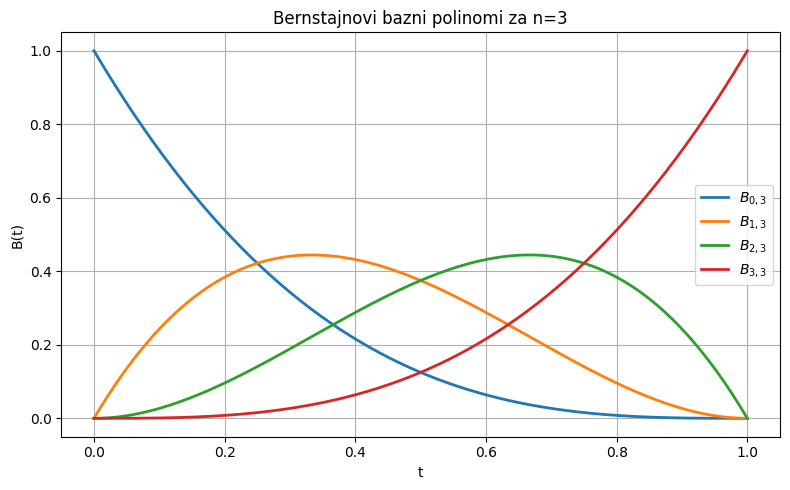

In [67]:
plt.figure(figsize=(8, 5))
labels = ['$B_{0,3}$', '$B_{1,3}$', '$B_{2,3}$', '$B_{3,3}$']
for i in range(4):
    plt.plot(t_vals, bernstein(i, 3, t_vals), label=labels[i], linewidth=2)
plt.xlabel('t'); plt.ylabel('B(t)')
plt.title('Bernstajnovi bazni polinomi za n=3')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

***

**Задатак 4.** 
Безијерове криве се најчешће користе за апроксимацију (где крива пролази близу, али не нужно кроз контролне тачке). Међутим, у роботици и анимацији често је потребно решити проблем **интерполације**: пронаћи криву која пролази **тачно** кроз задати скуп тачака (нпр. робот мора да погоди тачне чекпоинте).

Тачка на **кубној** Безијеровој кривој $B(t)$ за параметар $t \in [0, 1]$ одређена је са 4 контролне тачке ($P_0, P_1, P_2, P_3$) помоћу Бернштајнових полинома:
$$B(t) = (1-t)^3 P_0 + 3t(1-t)^2 P_1 + 3t^2(1-t) P_2 + t^3 P_3.$$

**а) Имплементација (Векторизовани De Casteljau):**
Написати функцију `de_casteljau(control_points, t)` која коришћењем **троугаоне итеративне шеме** рачуна координате тачке на кривој. Ова функција ће вам служити за исцртавање криве након што одредите непознате контролне тачке.

Овај алгоритам је **троугаони поступак** (сличан Невиловом). Ако су $\beta_0^{(0)}, \dots, \beta_n^{(0)}$ контролне тачке, тада се тачка на кривој (за конкретно $t$) рачуна итеративним "линеарним" комбинацијама:
$$\beta_i^{(k)} = (1-t)\beta_i^{(k-1)} + t\beta_{i+1}^{(k-1)},\qquad i=0,1,\dots,n-k,$$
где је $\beta_i^{(0)}$ почетна координата $i$-те контролне тачке. Коначна тачка на кривој је $\beta_0^{(n)},$ где је $n$ степен криве. Дакле, са сваком итерацијом алгоритма (бројач је $k$) се број контролних тачака $\beta_0^{(k)}, \dots, \beta_{n-k}^{(k)}$ смањује за 1.

Функција `de_casteljau(control_points, t)` прима улазне податке:
*   `control_points`: матрицу контролних тачака димензије $(n+1) \times 2$.
*   `t`: **низ** временских тренутака (вектор димензије $M$).


Формула за ажурирање низа тачака у $k$-том кораку гласи:
$$\beta^{(k)} = (1-t) \cdot \beta^{(k-1)}[:-1] + t \cdot \beta^{(k-1)}[1:]$$
где је $\beta^{(0)}$ почетни низ контролних тачака. Коначан резултат је $\beta^{(n)}$.

Функција треба да израчуна координате тачака на кривој за све вредности $t$ **истовремено**. 
**Захтев:** У имплементацији је дозвољено користити **само једну петљу** (петљу која иде по слојевима редукције, тј. по степену криве). Није дозвољено користити петљу за пролазак кроз низ `t`.

(5 поена)

#### 1. Интуиција иза формуле 
De Casteljau алгоритам ради на принципу узастопне линеарне интерполације. Замислите да формула:
$$\beta_i^{(k)} = (1-t)\beta_i^{(k-1)} + t\beta_{i+1}^{(k-1)}$$
значи: *"Нова тачка се налази на дужи између две старе тачке, померена за проценат $t$ ка другој тачки."*

In [68]:
def de_casteljau(control_points, t):
    t = np.asarray(t)
    M = len(t)
    # size(control_points) = (n+1)x2
    beta = control_points[:, np.newaxis,:] # nova osa za svaki vremenski interval
    beta = np.tile(beta, (1, M, 1)) # size(beta) = (n+1) x M x2 - svaka tacka u svakom vremenskom intervalu

    t_col = t[np.newaxis, :, np.newaxis] # 1 x M x 1

    n = len(control_points) - 1
    for _ in range(1, n + 1):
        beta = (1 - t_col) * beta[:-1] + t_col * beta[1:]
        # beta[:-1] = b0, b1, b2, ... b_n-1
        # beta[1:]  = b1, b2, b3, ... b_n
    return beta[0]

**б) Интерполација (Инверзни проблем):**

Робот мора да прође тачно кроз 4 задате тачке у одређеним временским тренуцима:
*   $D_0 = (0, 0)$ у $t=0$
*   $D_1 = (2, 4)$ у $t=1/3$
*   $D_2 = (8, 4)$ у $t=2/3$
*   $D_3 = (10, 0)$ у $t=1$

Ваш задатак је да пронађете непознате **контролне тачке** $P_0, P_1, P_2, P_3$ које дефинишу овакву криву.
1.  На основу својства крајњих тачака, одредити $P_0$ и $P_3$.
2.  За $t=1/3$ и $t=2/3$, поставити систем линеарних једначина по непознатим тачкама $P_1$ и $P_2$ користећи формулу за $B(t)$.
3.  Решити систем (матрично или аналитички) и израчунати координате тачака $P_1$ и $P_2$.

(5 поена)

**Разлика између $P$ и $D$:**
*   $P_i$ су **контролне тачке** (Control Points). Оне дефинишу облик, али крива (обично) не пролази кроз $P_1$ и $P_2$.
*   $D_i$ су **тачке података** (Data Points). Крива мора проћи тачно кроз њих.

**Како поставити систем једначина (Део б):**
Формула за криву је:
$$B(t) = (1-t)^3 P_0 + \mathbf{3t(1-t)^2 P_1} + \mathbf{3t^2(1-t) P_2} + t^3 P_3$$
Знамо да је $P_0 = D_0$ и $P_3 = D_3$. Непознате су нам $P_1$ и $P_2$.
Када убацимо услов да крива пролази кроз $D_1$ у тренутку $t=1/3$, добијамо:
$$D_1 - (1-t)^3 P_0 - t^3 P_3 = 3t(1-t)^2 \mathbf{P_1} + 3t^2(1-t) \mathbf{P_2}$$
(за $t=1/3$).

Ово води ка систему облика $\mathbf{A}\mathbf{x} = \mathbf{b}$, где је вектор непознатих $\mathbf{x} = [P_1, P_2]^T$. Матрица $\mathbf{A}$ садржи коефицијенте који зависе од $t$, а вектор $\mathbf{b}$ садржи познате тачке $D$ и $P_0, P_3$.

In [69]:
def B_koef(t):
    return np.array([(1-t)**3, 3*t*(1-t)**2, 3*t**2*(1-t), t**3])

D = np.array([[0,0],[2,4],[8,4],[10,0]], dtype=float)
t = np.array([0, 1/3, 2/3, 1], dtype=float)

# znamo da je P_0 = D_0 i P_3 = D_3
P0 = D[0].copy()
P3 = D[3].copy()

A = np.array([B_koef(1/3)[1:3], B_koef(2/3)[1:3]])
# A sadrzi 3t(1-t)^2 i 3t^2(1-t)

def get_b(t_val, Di):
    k = B_koef(t_val)
    return Di - k[0]*P0 - k[3]*P3

b = np.array([get_b(1/3, D[1]), get_b(2/3, D[2])])
# b sadrzi D1-(1-t)^3 P0 - t^3 P3 i D2-(1-t)^3 P0 - t^3 P3


# Resavamo jednacinu Ax = b i to po x koordinati i po y koordinati,
#   pri cemu je x = [P1 P2]^T
# Ax = b[:,0] i Ay = b[:,1]
x = np.linalg.solve(A, b[:,0])
y = np.linalg.solve(A, b[:,1])
P1 = np.array([x[0], y[0]])
P2 = np.array([x[1], y[1]])

print(f"P0 = {P0} \n P1 = {P1} \n P2 = {P2} \n P3 = {P3}")

P0 = [0. 0.] 
 P1 = [-2.66666667  6.        ] 
 P2 = [12.66666667  6.        ] 
 P3 = [10.  0.]


**в) Визуелизација:**
Приказати на истом графику:
1.  Задате тачке $D_0, \dots, D_3$ (као црвене крстиће) – циљеви кроз које робот пролази.
2.  Израчунате контролне тачке $P_0, \dots, P_3$ (као плаве кружиће) и њихов полигон (испрекидана линија).
3.  Резултујућу криву (користећи функцију из дела а).

(5 поена)

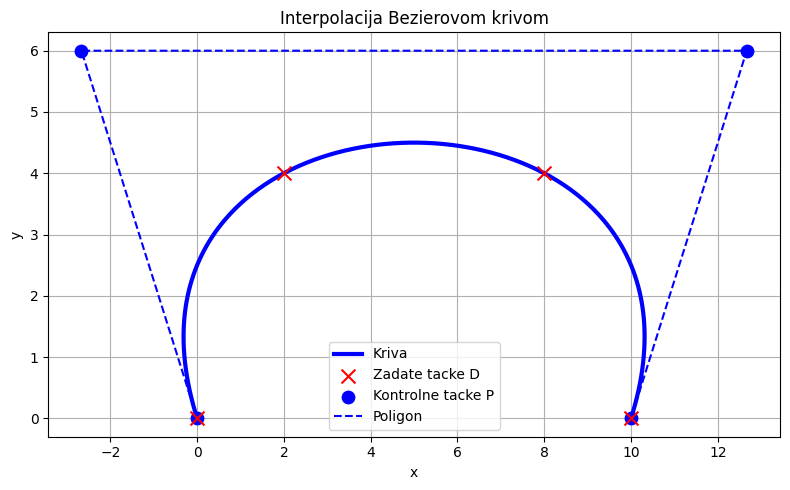

In [70]:
control_pts = np.array([P0, P1, P2, P3])
t_plot = np.linspace(0, 1, 300)
kriva = de_casteljau(control_pts, t_plot)

plt.figure(figsize=(8, 5))

plt.plot(kriva[:,0], kriva[:,1], 'b-', linewidth=3, label='Kriva')
plt.scatter(D[:,0], D[:,1], c='red', marker='x', s=100, zorder=10, label='Zadate tacke D')
plt.scatter(control_pts[:,0], control_pts[:,1], c='blue', marker='o', s=80, zorder=5, label='Kontrolne tacke P')
plt.plot(control_pts[:,0], control_pts[:,1], 'b--', label='Poligon')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolacija Bezierovom krivom')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

На крајњем графику ћете приметити да су израчунате контролне тачке $P_1$ и $P_2$ често "шире" или даље од тачака пролаза $D_1$ и $D_2$. То је зато што контролне тачке морају снажно да "вуку" криву како би је натерале да прође кроз жељене чекпоинте.

г) **Примена (Планирање путање):**
Робот треба да стигне од $Start(0, 0)$ до $Goal(10, 10)$, заобилазећи препреку на $(5, 5)$. Дефинисати 4 контролне тачке ($P_0, P_1, P_2, P_3$) тако да путања заобиђе препреку. Израчунати и нацртати путању за $t \in [0, 1]$.

1. Kontrolne tačke $P_0$ i $P_3$ dobijamo direktno, s obzirom da početak i kraj putanje moraju biti $(0,0)$ i (10, 10)
2. Možemo dobiti $P_1$ i $P_2$ sledećim algoritmom
    1. Definisati start, goal i tačku koja predstavlja prepreku kao i razdaljinu od prepreke (tj koliko želimo da je zaobiđemo)
    2. Odrediti vektora od početka do cilja. Duž te putanje, $P_0$ će se nalaziti na $0/3$ putanje, $P_1$ na $1/3$, $P_2$ na $2/3$ i $P_3$ na $3/3$, tj na kraju.
    3. Potrebno je još pomeriti $P_1$ i $P_2$ duž normale na dati pravac i to zavisno od izabranog rastojanja

In [71]:
start = np.array([0.0, 0.0])
goal  = np.array([10.0, 10.0])
obs   = np.array([5.0, 5.0])
r     = 3

# Vektor normalan na pravac start->goal
d = goal - start
d_norm = d / np.linalg.norm(d)
normal = np.array([-d_norm[1], d_norm[0]])  # rotacija za 90 kako bi dobili normalu

# Pomeramo kontrolne tačke
P0 = start.copy()
P1 = start + d/3 + normal * r
P2 = start + 2*d/3 + normal * r
P3 = goal.copy()

д) **Визуелизација:** Приказати путању, контролне тачке и њихов конвексни омотач (полигон). Проверити да ли путања излази из оквира овог полигона.

(10 поена)

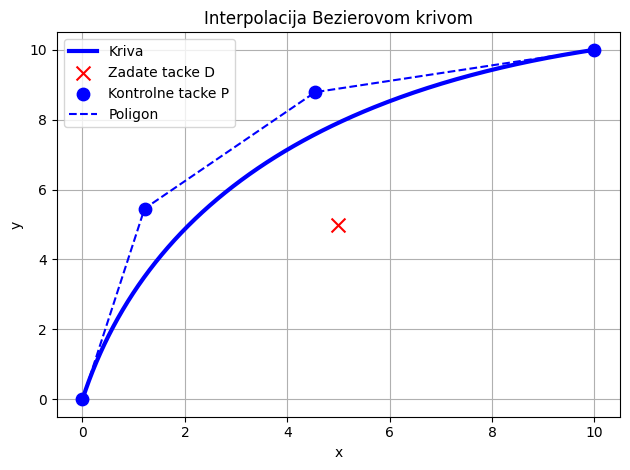

In [72]:
control_pts = np.array([P0, P1, P2, P3])
t_plot = np.linspace(0, 1, 300)
kriva = de_casteljau(control_pts, t_plot)

plt.plot(kriva[:,0], kriva[:,1], 'b-', linewidth=3, label='Kriva')
plt.scatter(obs[0], obs[1], c='red', marker='x', s=100, zorder=10, label='Zadate tacke D')
plt.scatter(control_pts[:,0], control_pts[:,1], c='blue', marker='o', s=80, zorder=5, label='Kontrolne tacke P')
plt.plot(control_pts[:,0], control_pts[:,1], 'b--', label='Poligon')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolacija Bezierovom krivom')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

***

**Задатак 5.**
У машинском учењу и обради слике, често је потребно утврдити колико су две слике (или два дела слике) слични. Скаларни производ матрица дефинисан преко трага:
$$\langle A, B \rangle = \text{tr}(A^T B)$$
нам омогућава да дефинишемо **Косинусну сличност** између матрица $A$ и $B$:
$$\text{Sim}_{cos}(A, B) = \frac{\text{tr}(A^T B)}{\|A\|_F \|B\|_F}$$
Где је $\|A\|_F = \sqrt{\text{tr}(A^T A)}$ Фробенијусова норма. Ова мера враћа вредност у опсегу $[-1, 1]$ (за ненегативне пикселе $[0, 1]$).

Поред косинусне сличности, често се користи и **Еуклидско растојање** (L2 дистанца):
$$\text{Dist}_{L2}(A, B) = \|A - B\|_F$$

**Циљ:** Имплементирати ове мере, упоредити их и применити за проналажење објеката на слици (*Template Matching*).

**а) Функција:** Написати функцију `matrix_cosine_similarity(A, B)` користећи `np.trace`.

(5 поена)

In [73]:
def matrix_cosine_similarity(A, B):
    div = np.sqrt(np.trace(A.T@A) * np.trace(B.T@B))
    return np.trace(A.T@B)/div

def euclid_distance(A, B):
    temp = A - B
    return np.sqrt(np.trace(temp.T@temp))

**Припрема података:**

Покренути код испод за учитавање слике и припрему *grayscale* матрице:

In [74]:
import scipy.datasets as scd
import cv2

Text(0.5, 1.0, 'Originalna slika')

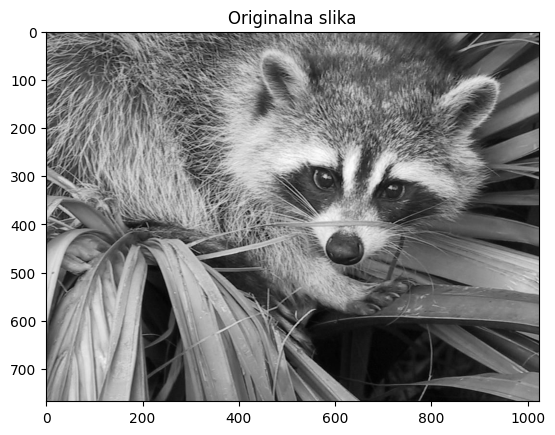

In [75]:
rakun=scd.face()
sk_vredn=rakun/255
rakun_gray = sk_vredn @ [0.2126, 0.7152, 0.0722]
rakun_gray.shape
plt.imshow(rakun_gray, cmap="gray")
plt.title("Originalna slika")

**б) Идентитет:** Програмски потврдити да је $\|T\|_F^2 = \text{tr}(T^T T)$ (уз толеранцију, нпр. `1e-10`):.

(5 поена)

In [76]:
T = np.random.randn(4, 4)
fro_sq = np.linalg.norm(T, 'fro') ** 2
tr = np.trace(T.T @ T)

assert np.isclose(fro_sq, tr, atol=1e-10), "Jednakost netacna!"
print("Jednakost tacna")

Jednakost tacna


**в) Template Matching:**

1.  Исећи део слике (нпр. њушку) као шаблон $T$ (*template*).
2.  Исећи други део исте величине (нпр. лишће) као шум  $N$ (*noise*).
3.  Израчунати Косинусну сличност за парове $(T, T)$ и $(T, N)$.
4.  Израчунати L2 дистанцу за парове $(T, T)$ и $(T, N)$.
5.  Дискусија: Упоредити резултате. Која вредност указује на "идентичност" код косинусне сличности, а која код L2 дистанце?


(5 поена)

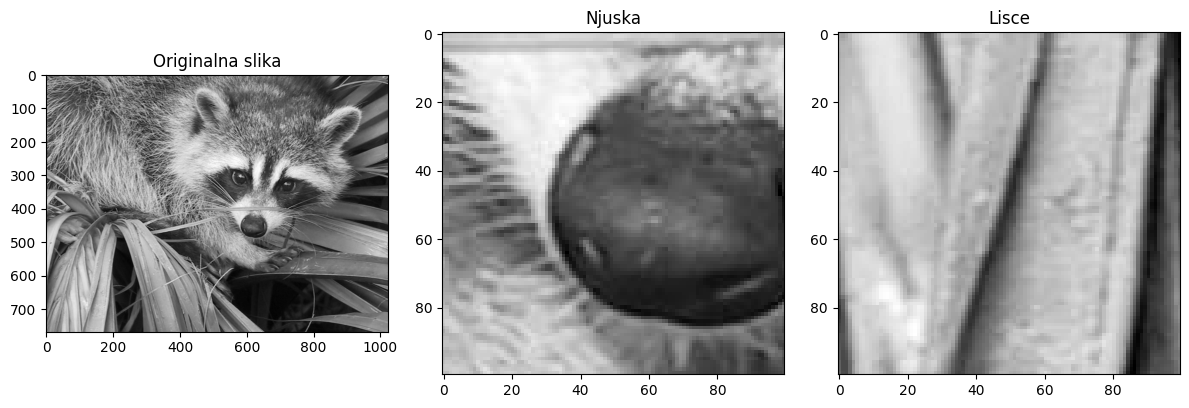

(T, T): Kosinusna: 1.0 L2: 0.0
(T, N): Kosinusna: 0.90165120866253 L2: 32.518286141570755


In [77]:
T = rakun_gray[400:500, 550:650]
N = rakun_gray[600:700, 100:200]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rakun_gray, cmap="gray")
axes[0].set_title("Originalna slika")

axes[1].imshow(T, cmap="gray")
axes[1].set_title("Njuska")

axes[2].imshow(N, cmap="gray")
axes[2].set_title("Lisce")

plt.tight_layout()
plt.show()

cos_TT = matrix_cosine_similarity(T, T)
cos_TN = matrix_cosine_similarity(T, N)

l2_TT = euclid_distance(T, T)
l2_TN = euclid_distance(T, N)

print("=" * 45)
print(f"(T, T): Kosinusna: {cos_TT} L2: {l2_TT}")
print(f"(T, N): Kosinusna: {cos_TN} L2: {l2_TN}")
print("=" * 45)


Kod kosinusne sličnosti vrednost $1$ označava identične matrice, dok kod $L2$ distance $0$ označava identičnost.

Za ovaj primer možemo videti da kosinusna sličnost i kod $(T, N)$ primera daje dobar rezultat, odnosno da su uzorci slični, dok $L2$ distanca pokazuje da se uzorci dosta razlikuju.

**г) Матрица сличности и Кластеризација:**

1.  Исећи **5 различитих делова** $P_i$ (patches) димензија $50 \times 50$:
    *   3 дела која захватају сличну текстуру (нпр. крзно).
    *   2 дела која захватају позадину (лишће).
    *   Сачувати их у листу `patches`.
2.  Креирати **Матрицу сличности** $S$ ($5 \times 5$), где је $S_{i,j}$ косинусна сличност између $P_i$ и $P_j$.
3.  Приказати матрицу користећи `heatmap` или `imshow`.
4.  **Кластеризација (Дендрограм):** Приказати хијерархијско груписање ових делова (користећи `scipy.cluster.hierarchy`). Да ли дендрограм исправно групише делова крзна одвојено од делова лишћа?


(5 поена)

In [78]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [79]:
tekst_1 = rakun_gray[200:250, 50:100]
tekst_2 = rakun_gray[200:250, 100:150]
tekst_3 = rakun_gray[200:250, 150:200]
pozad_1 = rakun_gray[450:500, 100:150]
pozad_2 = rakun_gray[500:550, 100:150]
patches = [tekst_1, tekst_2, tekst_3, pozad_1, pozad_2]
n = len(patches)

In [80]:
S = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            S[i, j] = 1
        elif i > j: 
            S[i, j] = S[j, i]
        else:
            S[i, j] = matrix_cosine_similarity(patches[i], patches[j])
print("Matrica slicnosti S:")
print(np.round(S, 4))

Matrica slicnosti S:
[[1.     0.9564 0.9533 0.931  0.9352]
 [0.9564 1.     0.9677 0.9375 0.948 ]
 [0.9533 0.9677 1.     0.9431 0.9512]
 [0.931  0.9375 0.9431 1.     0.9602]
 [0.9352 0.948  0.9512 0.9602 1.    ]]


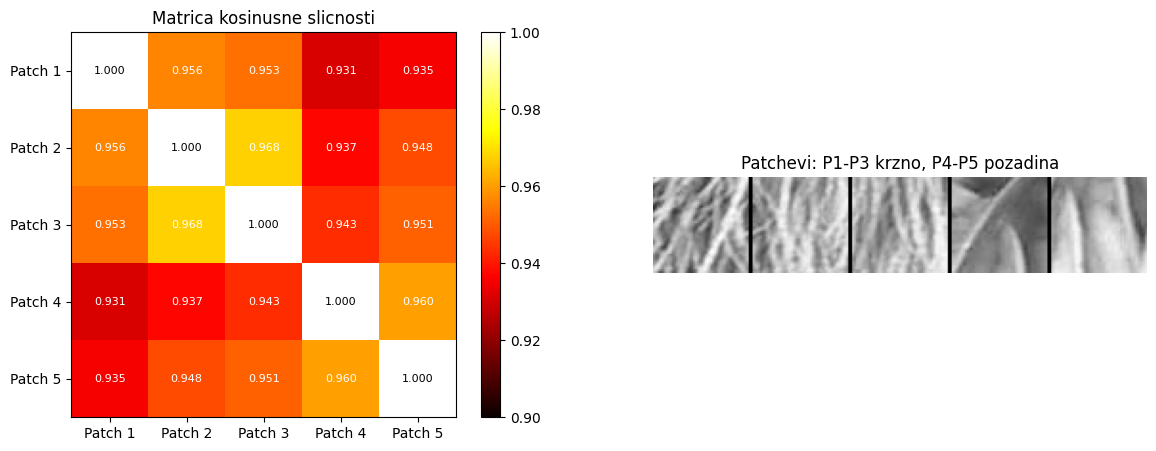

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(S, cmap="hot", vmin=0.9, vmax=1.0)
axes[0].set_title("Matrica kosinusne slicnosti")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels([f"Patch {i+1}" for i in range(n)])
axes[0].set_yticks(range(n)); axes[0].set_yticklabels([f"Patch {i+1}" for i in range(n)])
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f"{S[i,j]:.3f}", ha="center", va="center", fontsize=8,
                     color="white" if S[i,j] < 0.97 else "black")
plt.colorbar(im, ax=axes[0])

grid = np.zeros((50, 5*50 + 4*2), dtype=float)
for idx, p in enumerate(patches):
    grid[:, idx*52:idx*52+50] = p
axes[1].imshow(grid, cmap="gray")
axes[1].set_title("Patchevi: P1-P3 krzno, P4-P5 pozadina")
axes[1].axis("off")

plt.show()

/var/folders/sh/ggzbpg817b18jq_ls_9jggrc0000gn/T/ipykernel_12394/1942531527.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(1 - S, 'ward')


Text(0.5, 1.0, 'Груписање делова слике')

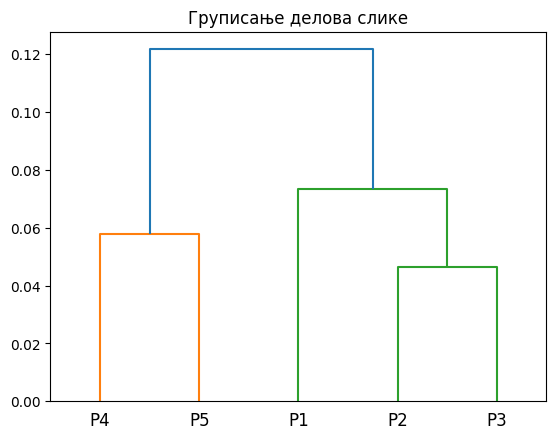

In [82]:
Z = linkage(1 - S, 'ward')
plt.figure()
dendrogram(Z, labels=["P1", "P2", "P3", "P4", "P5"])
plt.title("Груписање делова слике")

**д) Визуелизација: "Sliding Window" претрага (Heatmap)**

Ово је примитиван облик детекције објеката. Желимо да пронађемо где се одређени део налази на слици.

1.  Изаберите један део слике као **Template** $T$ (нпр. њушка ракуна).
2.  Имплементирати алгоритам **клизног прозора (sliding window)**:
    *   Пролазити кроз оригиналну слику (или мањи регион ради брзине).
    *   У сваком кораку исећи део слике $W$ исте величине као $T$.
    *   Израчунати сличност између $W$ и $T$.
3.  Резултат чувати у новој матрици (мапи сличности).
4.  Приказати оригиналан $T$ и добијену **мапу сличности (heatmap)**. Најсветлија тачка на мапи треба да одговара позицији шаблона на слици.
5. **OpenCV имплементација:** Употребити функцију `cv2.matchTemplate` (са методом `TM_CCOEFF_NORMED`) да добијете мапу сличности.
3.  Приказати обе мапе једну поред друге. Да ли ваша имплементација даје сличан резултат као оптимизована OpenCV функција?

(5 поена)

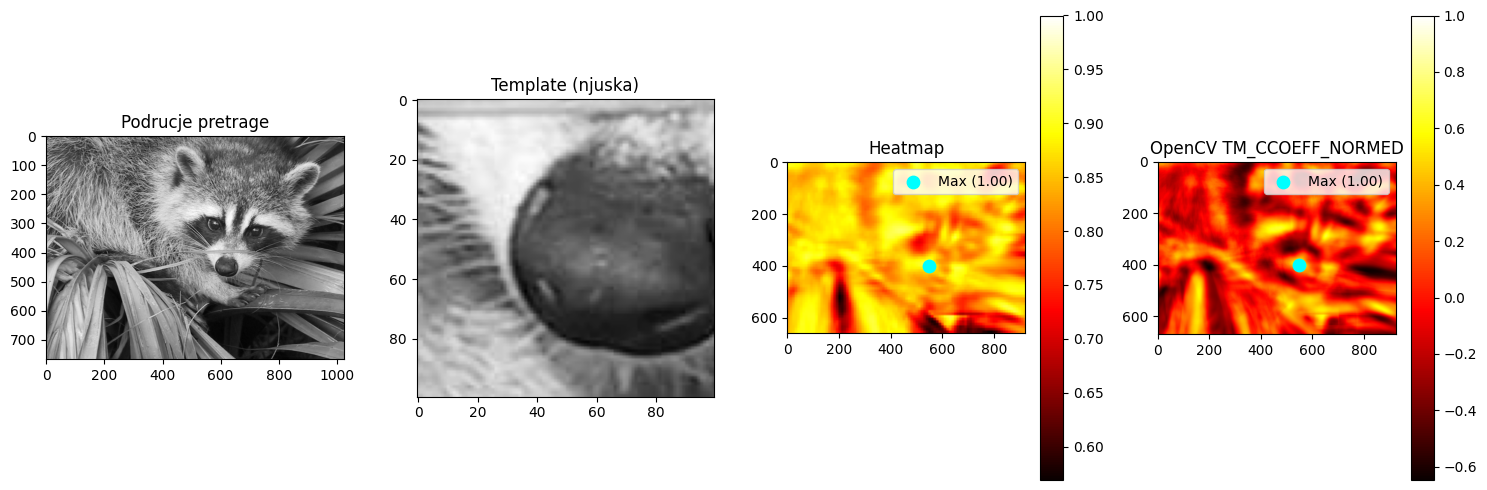

In [83]:
T = rakun_gray[400:500, 550:650] # template/njuska
th, tw = T.shape
ih, iw = rakun_gray.shape

step = 10
rows = range(0, ih - th, step)
cols = range(0, iw - tw, step)

heatmap = np.zeros((len(rows), len(cols)))

best_score = 0
best_row = 0
best_col = 0
for ri, r in enumerate(rows):
    for ci, c in enumerate(cols):
        h = matrix_cosine_similarity(rakun_gray[r:r+th, c:c+tw], T)
        if h > best_score:
            best_score = h
            best_row = r
            best_col = c
        heatmap[ri, ci] = h


img_f32  = rakun_gray.astype(np.float32)
tmpl_f32 = T.astype(np.float32)
cv_map   = cv2.matchTemplate(img_f32, tmpl_f32, cv2.TM_CCOEFF_NORMED)
_, cv_max, _, cv_loc = cv2.minMaxLoc(cv_map)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(rakun_gray, cmap="gray")
axes[0].set_title("Podrucje pretrage")

axes[1].imshow(T, cmap="gray")
axes[1].set_title("Template (njuska)")

im = axes[2].imshow(heatmap, cmap="hot", origin="upper",
                    extent=[cols[0], cols[-1], rows[-1], rows[0]])
axes[2].set_title("Heatmap")
plt.colorbar(im, ax=axes[2])

axes[2].scatter(best_col, best_row, c="cyan", s=80, zorder=5, label=f"Max ({best_score:.2f})")
axes[2].legend()

im2 = axes[3].imshow(cv_map, cmap="hot", origin="upper")
axes[3].set_title(f"OpenCV TM_CCOEFF_NORMED")
axes[3].scatter(cv_loc[0], cv_loc[1], c="cyan", s=80, zorder=5, label=f"Max ({cv_max:.2f})")
axes[3].legend()
plt.colorbar(im2, ax=axes[3])


plt.tight_layout()
plt.show()

Naša implementacija daje drugačije rezultate. Vrednosti su proporcionalne, ali kod OpenCV-a vrednosti su u rasponu $[-0.6, 1]$ a kod naše implementacije u opsegu $[0.6, 1]$. Standardna kosinusna sličnost daje slične vrednosti i za delove koji se ne poklapaju.

**ђ) Нумеричка стабилност и Нормализација (Zero-Centering)**

Сирове вредности пиксела могу заварати косинусну сличност (нпр. веома светао и веома таман део могу имати високу сличност ако су им вектори колинеарни).
Да бисмо ово решили, уводимо **нормализацију одузимањем средње вредности** (Zero-centering):
$$A_{norm} = A - \text{mean}(A)$$

1.  Модификовати функцију за косинусну сличност тако да прво "центрира" обе матрице (одузме њихов просек: $A - \text{mean}(A)$) пре рачунања трага. Ово је еквивалентно *Пирсоновој корелацији*.
2.  **Експеримент:** Искористити исту листу `patches` из дела **(г)**. Поново израчунати **Матрицу сличности** користећи нову (центрирану) функцију.
3.  **Визуелизација:** Приказати нову матрицу као *heatmap*.
4.  **Дискусија:** Упоредите овај *heatmap* са оним из дела (г). Да ли су контрасти између група (крзно vs позадина) сада израженији? Зашто је центрирање важно када поредимо текстуре које могу бити различито осветљене?

(5 поена)

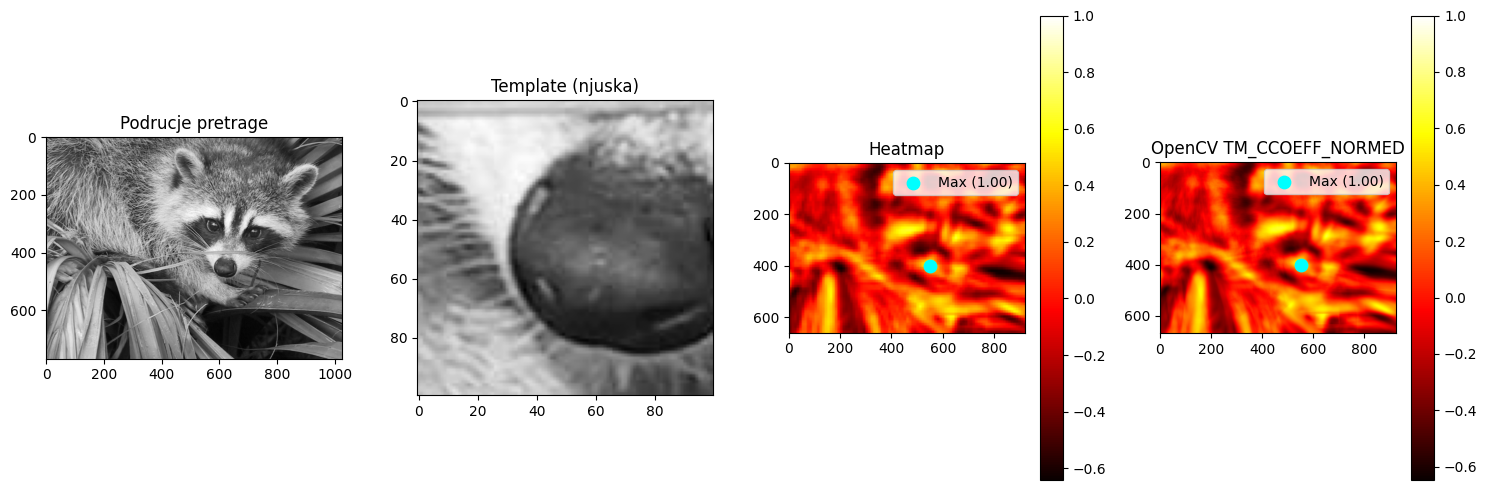

In [84]:
def matrix_cosine_similarity_mean(A, B):
    A_m = A - A.mean()
    B_m = B - B.mean()
    return matrix_cosine_similarity(A_m, B_m)


T = rakun_gray[400:500, 550:650] # template/njuska
th, tw = T.shape
ih, iw = rakun_gray.shape

step = 10
rows = range(0, ih - th, step)
cols = range(0, iw - tw, step)

heatmap = np.zeros((len(rows), len(cols)))

best_score = 0
best_row = 0
best_col = 0
for ri, r in enumerate(rows):
    for ci, c in enumerate(cols):
        h = matrix_cosine_similarity_mean(rakun_gray[r:r+th, c:c+tw], T)
        if h > best_score:
            best_score = h
            best_row = r
            best_col = c
        heatmap[ri, ci] = h


img_f32  = rakun_gray.astype(np.float32)
tmpl_f32 = T.astype(np.float32)
cv_map   = cv2.matchTemplate(img_f32, tmpl_f32, cv2.TM_CCOEFF_NORMED)
_, cv_max, _, cv_loc = cv2.minMaxLoc(cv_map)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(rakun_gray, cmap="gray")
axes[0].set_title("Podrucje pretrage")

axes[1].imshow(T, cmap="gray")
axes[1].set_title("Template (njuska)")

im = axes[2].imshow(heatmap, cmap="hot", origin="upper",
                    extent=[cols[0], cols[-1], rows[-1], rows[0]])
axes[2].set_title("Heatmap")
plt.colorbar(im, ax=axes[2])

axes[2].scatter(best_col, best_row, c="cyan", s=80, zorder=5, label=f"Max ({best_score:.2f})")
axes[2].legend()

im2 = axes[3].imshow(cv_map, cmap="hot", origin="upper")
axes[3].set_title(f"OpenCV TM_CCOEFF_NORMED")
axes[3].scatter(cv_loc[0], cv_loc[1], c="cyan", s=80, zorder=5, label=f"Max ({cv_max:.2f})")
axes[3].legend()
plt.colorbar(im2, ax=axes[3])


plt.tight_layout()
plt.show()

Sada naša implementacija i OpenCV daju identične rezultate, gde su bolje naglašene razlike između prozora na slici.

Centriranje je bitno kako bi izbegli uticaj osvetljenja na rezultat kosinusne sličnosti, tj ne želimo da dobijemo lažnu slicnost između dve slike ili rezultat koji ukazuje da su slike različite samo zbog osvetljenosti.

Primer:

Ako imamo dva piksela, tj vektora
$$
A = [0.1, 0.2, 0.3] \\
B = [0.5, 0.6, 0.7]
$$
odnos vrednosti u oba vektora je isti, ali je B osvetljeniji pa će kosinusna sličnost dati visok rezultat, jer je ugao između njih mali, ali želimo da dobijemo sličnost 1. Oduzimanjem $mean$ dobijamo
$$
A_c = [-0.1, 0, 0.1] \\
B = [-0.1, 0, 0.1]
$$
pa su sada identični i dobijamo sličnost $1.0$

Slično, za dva piksela koji su dosta osvetljeni
$$
A = [0.8, 0.9, 1.0] \\
B = [0.9, 0.9, 1.0]
$$
bi dobili veliku sličnost. Međutim, oduzimanjem $mean-a$ vidimo da je sličnost manja
$$
A_c = [-0.1, 0, 0.1] \\
B = [-0.033, -0.033, 0.067]
$$

**е) Примена: Image Retrieval концепт**

Замислите да имате базу од 1000 слика. Како бисте нашли слике најсличније упитној слици $Q$?

1.  (Теоријски део): Објаснити како бисте користили косинусну сличност и концепт из дела (а) да рангирате слике из базе по релевантности за упит $Q$.
2.  Која је предност косинусне сличности над Еуклидском дистанцом ако су слике различите осветљености (нпр. једна је тамнија, друга светлија)?

(15 поена)

Da bi našli najsličnije slike u bazi od 1000 slika, pri čemu je $Q$ upitna slika, možemo uraditi sledeće
1. Svaku sliku iz baze predstaviti kao matricu ili kao vektor piksela. Ukoliko je bitan samo sadržaj, a ne i boja, sliku čuvamo u grayscale.
2. Za svaku sliku $B_i$ iz baze računamo kosinusnu sličnost (sa normalizacijom) u odnosu na zadatu sliku $Q$.
3. Dobijeno rezultate sortiramo po sličnosti u opadajućem redosledu.
4. Vraćamo najbolji ili $k$ najboljih rezultata.

Ako je potrebno pronaći i u okviru slike
- U 3. koraku delimo svaku sliku $B_i$ na prozore a zatim nad njima primenjujemo kosinusnu sličnost. Kako moramo da dobijemo jednu vrednost po slici, možemo uzeti maksimalnu vrednost dobijenu (među svim prozorima) ili neku drugu normu.

Ako su slike u bazi i $Q$ različite veličine
- Moramo ih dovesti na iste veličine, najverovatnije primenom $windowing$-a nad većom slikom a zatim primeniti kosinusne sličnosti sa manjom. Padding i odsecanje su mogući ali menjaju sadržaj slike, pooling je takođe mogućnost ali i on menja sadržaj slike.

S obzirom na veliki broj slika i da je svaka kosinusna sličnost međusobno nezavisna, moguće je paralelizovati pretragu.


Kosinusna sličnost meri ugao između vektora, a ne dužinu. 
Zato dve slike iste scene koje su različito osvetljene će imati slične ili iste uglove (naročito nakon normalizacije) pa će sličnost biti velika. 

Sa druge strane, Euklidska distanca meri samo razliku intenziteta piksela, pa ako ima velike razlike u osvetljenosti biće i velika distanca, tj slike će pogrešno biti obeležene kao različite.

***